Practical 10:

Aim: To perform Hierarchical Clustering using agglomerative methods and interpret dendrongrams for cluster formation.

Name:Vedanti Ramde

Roll No:CS23513

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/ML_Dataset/Mall_Customers.csv"

In [ ]:
#STEP 3:SELECT FEATURES
df = pd.read_csv("/content/drive/MyDrive/ml_dataset/Mall_Customers.csv")
X= df[['Annual Income (k$)','Spending Score (1-100)']]

In [ ]:
# FEATURESCALING
scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)

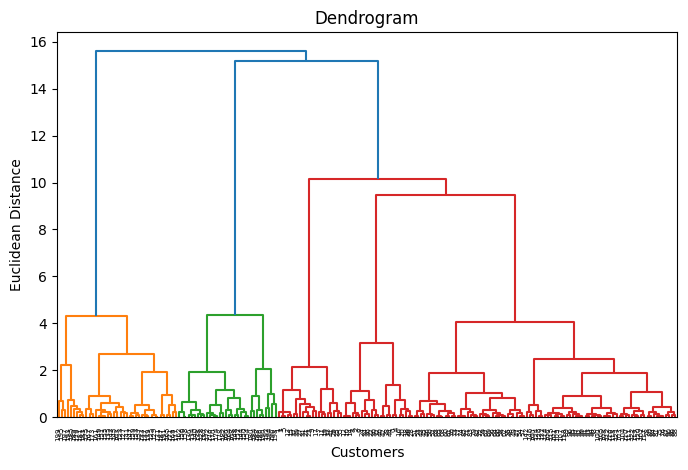

In [ ]:
plt.figure(figsize=(8,5))
# Re-import dendrogram and linkage to ensure they are the functions and not shadowed variables
from scipy.cluster.hierarchy import dendrogram, linkage
linked_data = linkage(X_scaled, method='ward')
dn = dendrogram(linked_data) # Changed variable name to 'dn'
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [ ]:
hc=AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
clusters= hc.fit_predict(X_scaled)

In [ ]:
df['Cluster']=clusters
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        3  
2        4  
3        3  
4        4  


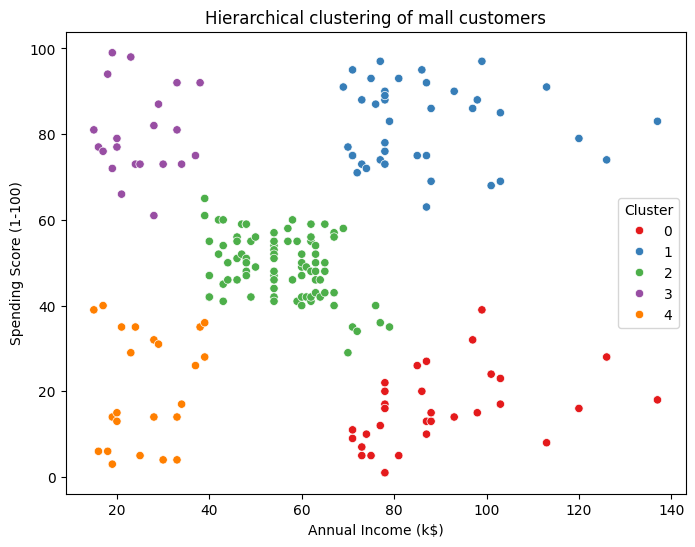

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='Cluster',data=df, palette="Set1")
plt.title("Hierarchical clustering of mall customers")
plt.show()